# V14 本地胜 A2、线上 Rating 更低：可复现诊断

## tl;dr

- **不存在未加权胜率崩塌。** V14 本地对固定 A2 为 149/18/33，纯胜率 74.50%；线上公开局为 66/0/21，纯胜率 75.86%。
- **表面矛盾来自量纲与赛程不同。** V14 线上纯胜率比 A2 高 10.78 个百分点，但 Public Rating 低 543.8 分。官方规则说明 Rating 变动取决于胜负和双方 Rating 差，金币差不计入。
- **对手池差异是强描述性解释。** V14 对手当前 Rating 代理均值 1757.9，A2 为 2061.4；V14 的 `>=2000` 对手占比仅 26.44%，A2 为 68.25%。这不是逐局赛前 Rating，不能作因果归因。
- **新增机制线上覆盖很低且不能持续。** 当前 runtime probe 覆盖 87 局，提交包动作完整复现 87 局；exact-A2 对手 0 局、发生 V14 重排 8 局、终局 shadow trusted 0 局。
- **同一 A2 复投也发生路径分叉。** 截至 2026-08-24T21:29:19.418007+08:00，团队 rank 1602、Rating 1519.3；两个 active 的相同 A2 复投 55743133/55743125 为 1519.3/1275.4，同一快照相差 243.9 分；旧 V14/A2/V13C 均已 inactive frozen。当前快照未配平两副本游戏数，因此不能把该分差当作通用噪声标准差。
- **543.8 分无法精确分摊。** 原始 episode/replay 不含逐局 pre/post Rating，任何精确 ELO 点数归因都会超出证据。


## Context & Methods

### 分析问题

解释为何 V14 在本地固定对手回放中胜过 A2，却以更低的 Kaggle Public Rating 结束线上窗口；同时检查 V14 新增的 exact-A2 SELL 队列重排是否在线上真实触发。

### Key Assumptions

1. 公开局只保留 `EPISODE_TYPE_PUBLIC`；validation 不进入 W/T/L。
2. `pure win rate = wins / games`；`outcome score = (wins + 0.5 * ties) / games`。
3. 对手强度使用同一时点团队榜 `Score` 作**赛后代理**，不是不可见的逐局赛前 Rating。
4. `>=2000` 是透明的敏感性切点，不是官方分层，也不是因果校正。
5. 只有提交包动作逐步 100% 复现的 replay 才进入机制归因。

### 官方 Evaluation 规则

本 notebook 使用本地 CLI receipt 校验下列规则：胜/负/平改变 Rating；改变量取决于双方 Rating 差；击败高 Rating 对手涨得更多；金币差不影响 Rating；只追踪最新两个 submission。报告不假设具体 ELO 常数或更新公式。


In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "font.family": "Arial Unicode MS",
    "axes.unicode_minus": False,
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_diagnosis_dir(start: Path) -> Path:
    for base in [start, *start.parents]:
        candidate = base / "kaggle_Kaggriculture" / "model" / "v14_online_diagnosis"
        if candidate.exists():
            return candidate
        if base.name == "v14_online_diagnosis" and (base / "metric_audit").exists():
            return base
    raise FileNotFoundError("找不到 kaggle_Kaggriculture/model/v14_online_diagnosis")


DIAGNOSIS_DIR = find_diagnosis_dir(Path.cwd().resolve())
REPORTING_DIR = DIAGNOSIS_DIR / "reporting"
OUTPUT_DIR = REPORTING_DIR / "outputs"
FIGURE_DIR = REPORTING_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METRIC_PATH = DIAGNOSIS_DIR / "metric_audit" / "independent_metric_audit.json"
PROBE_PATH = DIAGNOSIS_DIR / "runtime_probe" / "runtime_probe.json"
RUNTIME_ANALYSIS_PATH = DIAGNOSIS_DIR / "runtime_probe" / "runtime_analysis.json"
DATA_INVENTORY_PATH = DIAGNOSIS_DIR / "data_inventory.json"
RULES_PATH = REPORTING_DIR / "evaluation_rules_receipt.json"
LEADERBOARD_PATH = DIAGNOSIS_DIR / "raw" / "snapshot" / "kaggriculture_public_leaderboard.csv"


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


metric = load_json(METRIC_PATH)
probe = load_json(PROBE_PATH)
runtime_analysis = load_json(RUNTIME_ANALYSIS_PATH)
data_inventory = load_json(DATA_INVENTORY_PATH)
rules = load_json(RULES_PATH)
leaderboard = pd.read_csv(LEADERBOARD_PATH)

print("diagnosis_dir:", DIAGNOSIS_DIR)
print("metric audit:", metric["status"], metric["generated_at_utc"])
print("runtime probe replays:", probe["aggregate"]["replays"])
print("parent-A2 call match:", runtime_analysis["runtime"]["parent_a2_equivalence"]["equal_action_calls"], "/", runtime_analysis["runtime"]["calls"])
print("current team rank/rating:", data_inventory["current_snapshot"]["team"]["rank"], data_inventory["current_snapshot"]["team"]["rating"])
print("Evaluation receipt:", rules["retrieved_at_utc"], rules["content_sha256"])


diagnosis_dir: /Users/a1-6/Desktop/PycharmProjects/DS_completation/kaggle_Kaggriculture/model/v14_online_diagnosis
metric audit: PASS_WITH_NONIDENTIFIABLE_RATING_DELTAS 2026-08-24T13:02:14Z
runtime probe replays: 87
parent-A2 call match: 62543 / 62553
current team rank/rating: 1602 1519.3
Evaluation receipt: 2026-08-24T13:10:53Z 5ac05ca0977a0c200a203c46dc8ef031344000143bfa1e864723ee87aff62cfc


## Data

### 1. 校验官方规则 receipt 与源文件 hash

先验证官方 Evaluation 文本本身的 hash，再验证 metric audit 中列出的可本地解析源文件。hash 不一致时 notebook 直接失败。


In [2]:
assert hashlib.sha256(rules["content"].encode("utf-8")).hexdigest() == rules["content_sha256"]
assert len(rules["content"].encode("utf-8")) == rules["content_bytes_utf8"]

hash_rows = []
for item in metric["source_inventory"]:
    source_path = (DIAGNOSIS_DIR / item["path"]).resolve()
    actual = file_sha256(source_path)
    volatile_snapshot = item["path"].startswith("raw/snapshot/")
    hash_rows.append({
        "path": item["path"],
        "exists": source_path.exists(),
        "volatile_snapshot": volatile_snapshot,
        "expected_sha256": item["sha256"],
        "actual_sha256": actual,
        "match": actual == item["sha256"],
        "bytes": source_path.stat().st_size,
    })

hash_check = pd.DataFrame(hash_rows)
hash_check.to_csv(OUTPUT_DIR / "source_hash_check.csv", index=False)
immutable_mismatch = hash_check.loc[~hash_check["match"] & ~hash_check["volatile_snapshot"]]
assert immutable_mismatch.empty, immutable_mismatch
print("volatile snapshot drift rows:", int((~hash_check["match"] & hash_check["volatile_snapshot"]).sum()))
hash_check[["path", "bytes", "volatile_snapshot", "match"]]


volatile snapshot drift rows: 2


,path,bytes,volatile_snapshot,match
0,raw/v14/episodes_full.json,54985,False,True
1,raw/a2/episodes_full.json,39920,False,True
2,raw/v13c/episodes_full.json,54317,False,True
3,raw/snapshot/current_snapshot.json,8779,True,False
4,raw/snapshot/kaggriculture_public_leaderboard.csv,436421,True,False
5,../v14_first_principles_search/validation/runs...,6774388,False,True
6,../../playground/game_rules.html,29333,False,True


### 2. 从 official episode payload 独立重算 W/T/L

下列单元不依赖 audit 汇总数：直接从三份 `episodes_full.json` 过滤公开局、识别候选 submission seat、比较最终 reward，并连接同一时点团队榜作为对手当前 Rating 代理。


In [3]:
TARGETS = {
    "V14": {"key": "v14", "submission_id": 55722630, "public_rating": 1885.2},
    "A2 fixed": {"key": "a2", "submission_id": 55713355, "public_rating": 2429.0},
    "V13C": {"key": "v13c", "submission_id": 55719781, "public_rating": 2062.9},
}

leaderboard_score = leaderboard.set_index("TeamId")["Score"].to_dict()


def episode_rows(label: str, key: str, submission_id: int) -> pd.DataFrame:
    episodes = load_json(DIAGNOSIS_DIR / "raw" / key / "episodes_full.json")
    rows = []
    for episode in episodes:
        if episode.get("type") != "EPISODE_TYPE_PUBLIC":
            continue
        candidate = [a for a in episode["agents"] if int(a["submissionId"]) == submission_id]
        assert len(candidate) == 1, (episode["id"], len(candidate))
        candidate = candidate[0]
        opponent = [a for a in episode["agents"] if a is not candidate][0]
        if candidate["reward"] > opponent["reward"]:
            outcome = "W"
        elif candidate["reward"] < opponent["reward"]:
            outcome = "L"
        else:
            outcome = "T"
        rows.append({
            "model": label,
            "episode_id": int(episode["id"]),
            "end_time": pd.to_datetime(episode["endTime"]),
            "candidate_seat": int(candidate["index"]),
            "candidate_reward": float(candidate["reward"]),
            "opponent_reward": float(opponent["reward"]),
            "margin": float(candidate["reward"] - opponent["reward"]),
            "outcome": outcome,
            "opponent_team_id": int(opponent["teamId"]),
            "opponent_team": opponent["teamName"],
            "opponent_submission_id": int(opponent["submissionId"]),
            "opponent_rating_proxy": float(leaderboard_score[int(opponent["teamId"])]),
        })
    return pd.DataFrame(rows).sort_values(["end_time", "episode_id"]).reset_index(drop=True)


games = pd.concat(
    [episode_rows(label, cfg["key"], cfg["submission_id"]) for label, cfg in TARGETS.items()],
    ignore_index=True,
)


def wilson(wins: int, games_count: int, z: float = 1.959963984540054) -> tuple[float, float]:
    p = wins / games_count
    denom = 1 + z**2 / games_count
    centre = (p + z**2 / (2 * games_count)) / denom
    half = z * np.sqrt(p * (1 - p) / games_count + z**2 / (4 * games_count**2)) / denom
    return centre - half, centre + half


summary_rows = []
for label, cfg in TARGETS.items():
    part = games.loc[games["model"] == label]
    wins = int((part["outcome"] == "W").sum())
    ties = int((part["outcome"] == "T").sum())
    losses = int((part["outcome"] == "L").sum())
    ci_low, ci_high = wilson(wins, len(part))
    audited_dist = metric["online"][cfg["key"]]["opponent_distribution"]
    audited_strong = audited_dist.get("binary_2000_cut", {}).get("gte2000", audited_dist.get("gte2000"))
    summary_rows.append({
        "model": label,
        "submission_id": cfg["submission_id"],
        "public_rating": cfg["public_rating"],
        "games": len(part),
        "wins": wins,
        "ties": ties,
        "losses": losses,
        "pure_win_rate": wins / len(part),
        "outcome_score_rate": (wins + 0.5 * ties) / len(part),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "current_opponent_rating_proxy_mean": part["opponent_rating_proxy"].mean(),
        "current_opponent_rating_proxy_median": part["opponent_rating_proxy"].median(),
        "frozen_audit_opponent_rating_proxy_mean": audited_dist["rating_proxy"]["mean"],
        "frozen_audit_opponent_gte2000_share": audited_strong["share"],
    })

online_summary = pd.DataFrame(summary_rows)
online_summary.to_csv(OUTPUT_DIR / "online_summary.csv", index=False)

for _, row in online_summary.iterrows():
    audited = metric["online"][TARGETS[row["model"]]["key"]]["overall"]
    assert [row["wins"], row["ties"], row["losses"]] == [audited["wins"], audited["ties"], audited["losses"]]
    assert abs(row["pure_win_rate"] - audited["pure_win_rate"]) < 1e-6

online_summary[["model", "public_rating", "games", "wins", "ties", "losses", "pure_win_rate", "ci_low", "ci_high", "frozen_audit_opponent_rating_proxy_mean", "current_opponent_rating_proxy_mean", "frozen_audit_opponent_gte2000_share"]]


,model,public_rating,games,wins,ties,losses,pure_win_rate,ci_low,ci_high,frozen_audit_opponent_rating_proxy_mean,current_opponent_rating_proxy_mean,frozen_audit_opponent_gte2000_share
0,V14,1885.2,87,66,0,21,0.758621,0.659010,0.836358,1757.89,1771.711494,0.264368
1,A2 fixed,2429.0,63,41,0,22,0.650794,0.527515,0.756740,2061.41,2065.230159,0.682540
2,V13C,2062.9,86,53,0,33,0.616279,0.510629,0.711986,1998.98,1996.659302,0.604651


## Results

### Rating 与胜率方向相反，但并不矛盾

左图按公开 episode 直接重算未加权胜率及 Wilson 95% 区间；右图是各 submission 停止活跃时的 Public Rating。V14 的未加权胜率最高，却不是 Rating 最高者，直接说明这两者不能互换。V13C 以更低胜率获得更高 Rating，是第二个反例。


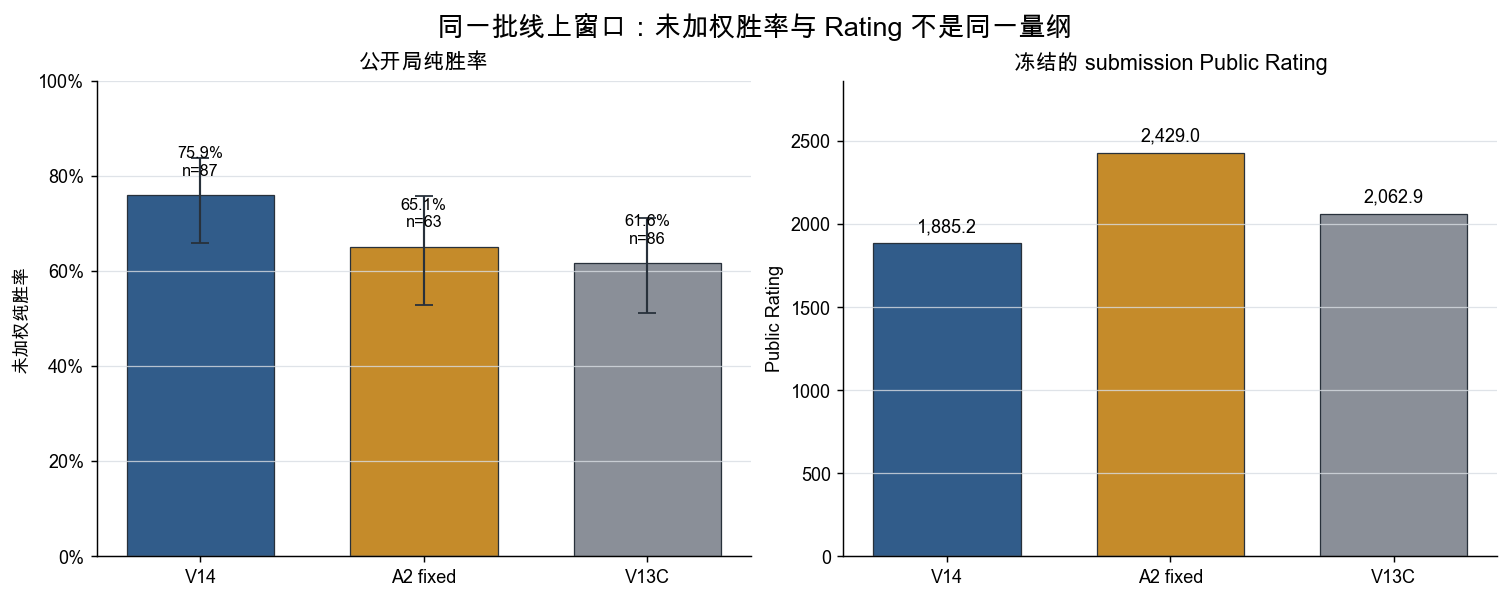

In [4]:
order = ["V14", "A2 fixed", "V13C"]
plot_df = online_summary.set_index("model").loc[order].reset_index()
colors = ["#315C8A", "#C58B2A", "#8A8F98"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)

ax = axes[0]
x = np.arange(len(plot_df))
y = plot_df["pure_win_rate"].to_numpy()
yerr = np.vstack([y - plot_df["ci_low"].to_numpy(), plot_df["ci_high"].to_numpy() - y])
bars = ax.bar(x, y, color=colors, edgecolor="#28313B", linewidth=0.7, width=0.66)
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="#28313B", capsize=5, linewidth=1.2)
ax.set_xticks(x, plot_df["model"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("未加权纯胜率")
ax.set_title("公开局纯胜率")
for bar, rate, n in zip(bars, y, plot_df["games"]):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.035, f"{rate:.1%}\nn={n}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", color="#D8DDE3", linewidth=0.7, alpha=0.8)

ax = axes[1]
ratings = plot_df["public_rating"].to_numpy()
bars = ax.bar(x, ratings, color=colors, edgecolor="#28313B", linewidth=0.7, width=0.66)
ax.set_xticks(x, plot_df["model"])
ax.set_ylim(0, max(ratings) * 1.18)
ax.set_ylabel("Public Rating")
ax.set_title("冻结的 submission Public Rating")
for bar, rating in zip(bars, ratings):
    ax.text(bar.get_x() + bar.get_width()/2, rating + 45, f"{rating:,.1f}", ha="center", va="bottom", fontsize=10)
ax.grid(axis="y", color="#D8DDE3", linewidth=0.7, alpha=0.8)

fig.suptitle("同一批线上窗口：未加权胜率与 Rating 不是同一量纲", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "01_metric_mismatch.png", bbox_inches="tight", facecolor="white")
plt.show()


### 高总胜率主要伴随更容易的对手构成

V14 约四分之三的对手当前 Rating 代理低于 2000，而 A2 约三分之二的对手在 2000 及以上；在 `>=2000` 段，V14 胜率还低于 A2。两层 Kitagawa 恒等分解把线上未调整的 `+10.78pp` 胜率差拆为 `+12.54pp` 对手构成项和 `-1.76pp` 层内表现项。该分解只描述当前代理分层，不能复原官方逐局 Rating 更新。


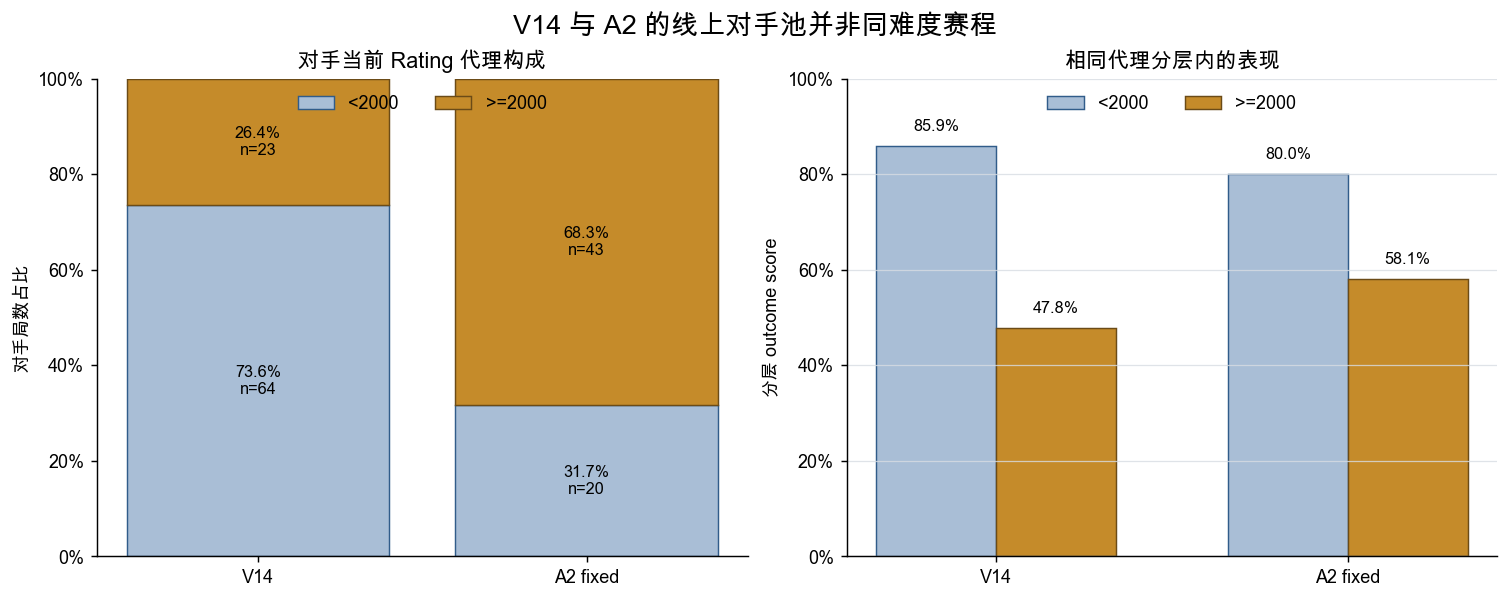

,model,lt2000_share,gte2000_share,lt2000_score,gte2000_score,lt2000_games,gte2000_games
0,V14,0.735632,0.264368,0.859375,0.478261,64,23
1,A2 fixed,0.317460,0.682540,0.800000,0.581395,20,43


In [5]:
mix_rows = []
for label, key in [("V14", "v14"), ("A2 fixed", "a2")]:
    cut = metric["online"][key]["opponent_distribution"]["binary_2000_cut"]
    mix_rows.append({
        "model": label,
        "lt2000_share": cut["lt2000"]["share"],
        "gte2000_share": cut["gte2000"]["share"],
        "lt2000_score": cut["lt2000"]["score_rate"],
        "gte2000_score": cut["gte2000"]["score_rate"],
        "lt2000_games": cut["lt2000"]["games"],
        "gte2000_games": cut["gte2000"]["games"],
    })
mix_summary = pd.DataFrame(mix_rows)
mix_summary.to_csv(OUTPUT_DIR / "opponent_mix_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
x = np.arange(len(mix_summary))

ax = axes[0]
low = ax.bar(x, mix_summary["lt2000_share"], color="#A9BED6", edgecolor="#315C8A", linewidth=0.8, label="<2000")
high = ax.bar(x, mix_summary["gte2000_share"], bottom=mix_summary["lt2000_share"], color="#C58B2A", edgecolor="#6B4B17", linewidth=0.8, label=">=2000")
ax.set_xticks(x, mix_summary["model"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("对手局数占比")
ax.set_title("对手当前 Rating 代理构成")
ax.legend(frameon=False, ncol=2, loc="upper center")
for i, row in mix_summary.iterrows():
    ax.text(i, row["lt2000_share"] / 2, f"{row['lt2000_share']:.1%}\nn={int(row['lt2000_games'])}", ha="center", va="center", fontsize=9)
    ax.text(i, row["lt2000_share"] + row["gte2000_share"] / 2, f"{row['gte2000_share']:.1%}\nn={int(row['gte2000_games'])}", ha="center", va="center", fontsize=9)

ax = axes[1]
width = 0.34
b1 = ax.bar(x - width/2, mix_summary["lt2000_score"], width, color="#A9BED6", edgecolor="#315C8A", linewidth=0.8, label="<2000")
b2 = ax.bar(x + width/2, mix_summary["gte2000_score"], width, color="#C58B2A", edgecolor="#6B4B17", linewidth=0.8, label=">=2000")
ax.set_xticks(x, mix_summary["model"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("分层 outcome score")
ax.set_title("相同代理分层内的表现")
ax.legend(frameon=False, ncol=2, loc="upper center")
ax.grid(axis="y", color="#D8DDE3", linewidth=0.7, alpha=0.8)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025, f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=9)

fig.suptitle("V14 与 A2 的线上对手池并非同难度赛程", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "02_opponent_mix.png", bbox_inches="tight", facecolor="white")
plt.show()
mix_summary


### V14 的新增机制在线上只在短暂 A2-compatible 前缀触发

本地 confirm 针对 exact A2：shadow 全程可信，72% 的局至少发生一次 SELL 队列重排。线上 runtime probe 则逐步复现已提交 archive；87 局中没有 exact-A2 或终局 trusted，但 8 局在对手尚未出现可观测偏离前发生过重排，随后 fail-close。机制不是完全未运行，而是覆盖很低且无法持续。

V14 有 62,543/62,553（99.984%）动作等于父 A2，79/87 局全程相同；21 个负局中 20 局为 719/719 父 A2 动作。本地平均 13.00 重排/局，线上只有 0.115/局，激活密度低 113.1 倍。8 局重排样本没有“禁用重排”的同 seed 反事实，不能据其 W/L 判断机制有效或有害。

0818–0820 留出的只是环境 seed；闭环对手仍固定 A2/r002，没有 holdout 对手策略谱系。该结论只适用于 probe 覆盖且 archive 动作 100% 复现的回放。


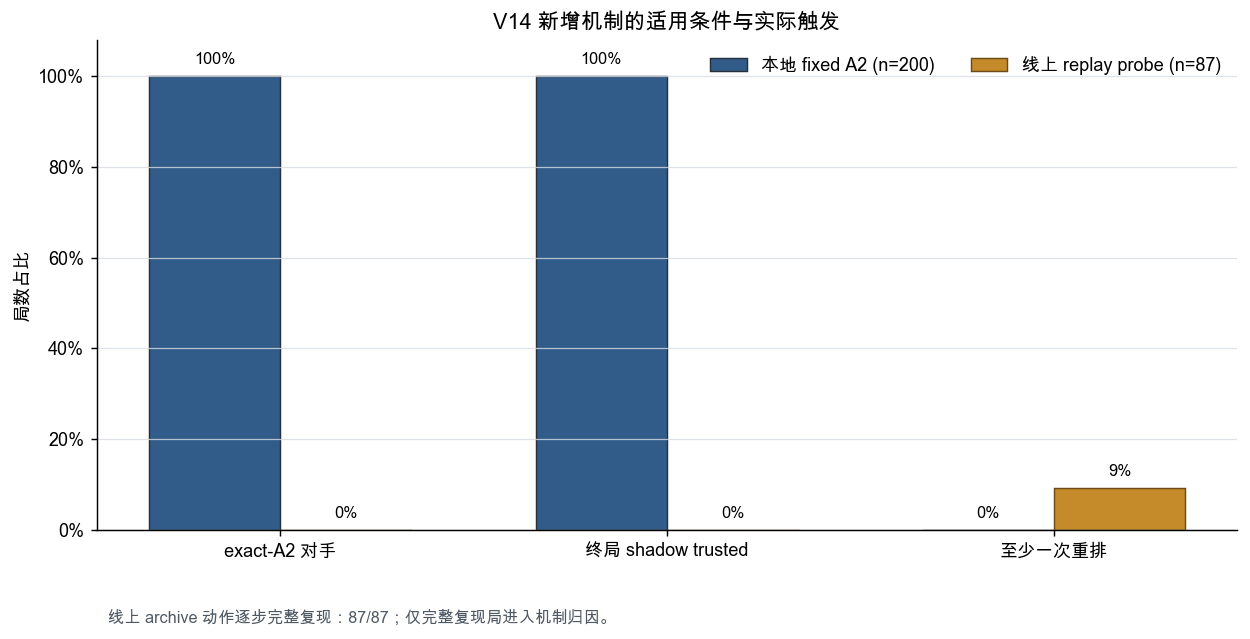

,cohort,games,exact_a2_share,shadow_trusted_end_share,games_with_reorder_share,archive_reproduction_share
0,本地 fixed A2,200,1.0,1.0,0.000000,NaN
1,线上 replay probe,87,0.0,0.0,0.091954,1.0


In [6]:
agg = probe["aggregate"]
local = metric["local_confirmatory"]["independent_recompute"]["vs_a2"]
local_ref = probe.get("local_confirmatory_reference", {}).get("by_anchor", {}).get("v12a2_no_shop_gate", {})
local_games = int(local_ref.get("games", local["games"]))

mechanism_summary = pd.DataFrame([
    {
        "cohort": "本地 fixed A2",
        "games": local_games,
        "exact_a2_share": 1.0,
        "shadow_trusted_end_share": local_ref.get("shadow_trusted_games", local_games) / local_games,
        "games_with_reorder_share": local_ref.get("games_with_reorder", 0) / local_games,
        "archive_reproduction_share": np.nan,
    },
    {
        "cohort": "线上 replay probe",
        "games": agg["replays"],
        "exact_a2_share": agg["exact_a2_opponent_games"] / agg["replays"],
        "shadow_trusted_end_share": agg["games_shadow_trusted_at_end"] / agg["replays"],
        "games_with_reorder_share": agg["games_with_v14_reorder"] / agg["replays"],
        "archive_reproduction_share": agg["archive_action_exact_reproduced"] / agg["replays"],
    },
])
mechanism_summary.to_csv(OUTPUT_DIR / "mechanism_summary.csv", index=False)

parent_eq = runtime_analysis["runtime"]["parent_a2_equivalence"]
loss_attr = runtime_analysis["runtime"]["loss_attribution"]
parent_equivalence_summary = pd.DataFrame([{
    "calls": runtime_analysis["runtime"]["calls"],
    "equal_action_calls": parent_eq["equal_action_calls"],
    "equal_action_rate": parent_eq["equal_action_rate"],
    "exact_action_games": parent_eq["exact_action_games"],
    "episodes": runtime_analysis["runtime"]["episodes"],
    "losses": loss_attr["losses"],
    "losses_exact_parent_a2_all_719_calls": loss_attr["losses_exact_parent_a2_all_719_calls"],
    "local_reorders_per_game": runtime_analysis["local_vs_online_mechanism"]["local_reorders_per_game"],
    "online_reorders_per_game": runtime_analysis["local_vs_online_mechanism"]["online_reorders_per_game"],
    "local_activation_multiple_over_online": runtime_analysis["local_vs_online_mechanism"]["local_activation_multiple_over_online"],
}])
parent_equivalence_summary.to_csv(OUTPUT_DIR / "parent_equivalence_summary.csv", index=False)

reorder_episode_rows = []
for episode in probe.get("episodes", []):
    selected = episode["selected_probe"]
    reorder_steps = selected.get("reorder_steps", [])
    if not reorder_steps:
        continue
    first_mismatch = selected.get("first_prediction_mismatch") or {}
    reorder_episode_rows.append({
        "episode_id": episode["episode_id"],
        "outcome": episode["outcome"],
        "margin": episode["margin"],
        "reorder_step_count": len(reorder_steps),
        "first_reorder_step": min(reorder_steps),
        "last_reorder_step": max(reorder_steps),
        "first_observable_mismatch_action_step": first_mismatch.get("action_step"),
        "first_shadow_fault_step": selected.get("first_shadow_fault_step"),
        "wrong_current_shadow_reorder_steps": len(selected.get("reorder_with_wrong_current_shadow_steps", [])),
    })
reorder_episode_summary = pd.DataFrame(reorder_episode_rows)
reorder_episode_summary.to_csv(OUTPUT_DIR / "reorder_episode_summary.csv", index=False)
assert len(reorder_episode_summary) == agg["games_with_v14_reorder"]
assert reorder_episode_summary["wrong_current_shadow_reorder_steps"].sum() == 0
assert (reorder_episode_summary["last_reorder_step"] < reorder_episode_summary["first_observable_mismatch_action_step"]).all()

metrics_to_plot = [
    ("exact_a2_share", "exact-A2 对手"),
    ("shadow_trusted_end_share", "终局 shadow trusted"),
    ("games_with_reorder_share", "至少一次重排"),
]
labels = [label for _, label in metrics_to_plot]
x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
local_vals = [mechanism_summary.loc[0, key] for key, _ in metrics_to_plot]
online_vals = [mechanism_summary.loc[1, key] for key, _ in metrics_to_plot]
b1 = ax.bar(x - width/2, local_vals, width, color="#315C8A", edgecolor="#28313B", linewidth=0.8, label=f"本地 fixed A2 (n={local_games})")
b2 = ax.bar(x + width/2, online_vals, width, color="#C58B2A", edgecolor="#6B4B17", linewidth=0.8, label=f"线上 replay probe (n={agg['replays']})")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("局数占比")
ax.set_title("V14 新增机制的适用条件与实际触发")
ax.legend(frameon=False, ncol=2, loc="upper right")
ax.grid(axis="y", color="#D8DDE3", linewidth=0.7, alpha=0.8)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=9)
ax.text(0.01, -0.19, f"线上 archive 动作逐步完整复现：{agg['archive_action_exact_reproduced']}/{agg['replays']}；仅完整复现局进入机制归因。", transform=ax.transAxes, fontsize=9, color="#4F5964")
fig.savefig(FIGURE_DIR / "03_mechanism_activation.png", bbox_inches="tight", facecolor="white")
plt.show()
mechanism_summary


### 时间路径与席位检查没有推翻主结论

- V14 前 40 局为 34/0/6，41–80 局为 30/0/10，最后 7 局为 2/0/5；最后阶段对手当前 Rating 代理均值升至 2074.2。该序列与后段回撤一致，但没有逐局 pre/post Rating，不能算出损失点数。
- V14 两席胜率仅差 1.47 个百分点，A2 两席仅差 0.81 个百分点；席位不足以解释 543.8 分差。
- V14 与 A2 线上未加权胜率差的 bootstrap 95% 区间为 -3.94pp 至 +25.62pp，包含 0；线上样本不支持“V14 泛化强度已显著胜过 A2”的推断。


In [7]:
comparison = metric["comparison"]
decomp = comparison["opponent_mix_diagnostics"]["two_bin_kitagawa_decomposition_at_2000"]
agg = probe["aggregate"]

analysis_summary = {
    "generated_from_notebook": True,
    "metric_audit_generated_at_utc": metric["generated_at_utc"],
    "runtime_probe_replays": agg["replays"],
    "runtime_probe_archive_exact_reproduced": agg["archive_action_exact_reproduced"],
    "runtime_probe_reorder_episodes": reorder_episode_summary.to_dict(orient="records"),
    "official_evaluation_receipt_sha256": rules["content_sha256"],
    "primary": {
        "v14_online": metric["online"]["v14"]["overall"],
        "a2_online": metric["online"]["a2"]["overall"],
        "v13c_online": metric["online"]["v13c"]["overall"],
        "v14_public_rating": metric["online"]["v14"]["public_simulation_rating"],
        "a2_public_rating": metric["online"]["a2"]["public_simulation_rating"],
        "v13c_public_rating": metric["online"]["v13c"]["public_simulation_rating"],
        "v14_minus_a2_rating": comparison["online_v14_vs_a2_unadjusted"]["v14_minus_a2_public_simulation_rating"],
        "v14_minus_a2_win_rate_pp": comparison["online_v14_vs_a2_unadjusted"]["v14_minus_a2_outcome_score_rate_pp"],
        "v14_minus_a2_win_rate_ci95_pp": comparison["online_v14_vs_a2_unadjusted"]["independent_difference_ci95_bootstrap_pp"],
    },
    "local": metric["local_confirmatory"],
    "opponent_mix": comparison["opponent_mix_diagnostics"],
    "path": comparison["path_diagnostics"],
    "seat": comparison["seat_diagnostics"],
    "runtime_probe": agg,
    "runtime_analysis": runtime_analysis,
    "data_inventory": data_inventory,
    "rating_attribution": metric["rating_attribution"],
    "epistemic_status": metric["epistemic_status"],
    "data_quality": metric["data_quality"],
    "source_inventory": metric["source_inventory"],
    "data_inventory_sha256": file_sha256(DATA_INVENTORY_PATH),
}

with (OUTPUT_DIR / "analysis_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(analysis_summary, handle, ensure_ascii=False, indent=2)

print(json.dumps({
    "v14_wtl": [analysis_summary["primary"]["v14_online"][k] for k in ["wins", "ties", "losses"]],
    "a2_wtl": [analysis_summary["primary"]["a2_online"][k] for k in ["wins", "ties", "losses"]],
    "rating_gap": analysis_summary["primary"]["v14_minus_a2_rating"],
    "mix_component_pp": decomp["opponent_mix_component_pp"],
    "within_bin_component_pp": decomp["within_bin_performance_component_pp"],
    "probe_replays": agg["replays"],
    "probe_exact_a2": agg["exact_a2_opponent_games"],
        "probe_reorder": agg["games_with_v14_reorder"],
        "probe_reorder_wtl": [
            int((reorder_episode_summary["outcome"] == "W").sum()),
            int((reorder_episode_summary["outcome"] == "T").sum()),
            int((reorder_episode_summary["outcome"] == "L").sum()),
        ],
        "probe_reorder_steps": int(reorder_episode_summary["reorder_step_count"].sum()),
        "wrong_current_shadow_reorder_steps": int(reorder_episode_summary["wrong_current_shadow_reorder_steps"].sum()),
    }, ensure_ascii=False, indent=2))


{
  "v14_wtl": [
    66,
    0,
    21
  ],
  "a2_wtl": [
    41,
    0,
    22
  ],
  "rating_gap": -543.8,
  "mix_component_pp": 12.5393,
  "within_bin_component_pp": -1.7566,
  "probe_replays": 87,
  "probe_exact_a2": 0,
  "probe_reorder": 8,
  "probe_reorder_wtl": [
    7,
    0,
    1
  ],
  "probe_reorder_steps": 10,
  "wrong_current_shadow_reorder_steps": 0
}


## Takeaways

### 证据分级

**已证实**

- V14 线上公开局为 66/0/21，未加权胜率没有低于本地 fixed-A2 结果。
- Public Rating 与未加权胜率不是同一指标；金币差不进入 Rating，双方 Rating 差会影响改变量。
- V14 与 A2 经历的是未配对、不同难度、不同时间顺序的赛程。
- V14 与 A2 的共同 opponent submission 为 0；V14 99.984% 动作等于父 A2，21 个负局中 20 局完全是父 A2 动作。
- runtime probe 在提交包动作逐步完整复现的覆盖回放中，新增重排仅在 8/87 局短暂触发，且没有一局保持终局 trusted。
- 0818–0820 只 holdout 环境 seed，没有 holdout 对手策略谱系。

**描述性证据**

- 同一时点团队榜代理显示，V14 对手显著更弱；两层分解显示，较容易的对手构成足以覆盖 V14 未调整胜率优势。
- 最后 7 局 2/5 与终局回撤一致。

**仍未知**

- 543.8 Rating 分分别由对手强度、路径顺序、更新参数与停赛冻结贡献多少。
- 精确更新公式、逐局双方赛前 Rating 与候选赛后 Rating。
- V14 对线上强对手池的真实因果提升；当前没有同 seed、同对手、双席位的线上配对实验。

### 建议的下一步

1. 保留本地 fixed A2/r002 作为“克制性”门槛，但新增按线上强度分层的异质专家联赛作为“泛化性”门槛。
2. 每次线上报告同时列 `W/T/L + outcome score + CI` 与 `Public Rating`，禁止再把两者合并成一个“得分”。
3. 未来若平台可得，逐局保存双方 pre-rating、候选 post-rating 与应用顺序；否则将 Rating 点数归因登记为不可识别。
4. 新增机制必须报告 exact-opponent 覆盖率、shadow trusted 率与触发率；局部克制策略不能只看 fixed-opponent 胜率。

### Further questions

- 线上匹配是否按即时 Rating 主动分层，以及 inactive submission 的冻结规则，现有数据只能观察相关路径。
- V14 在真实 `>=2000` 对手池只有 23 局，区间仍宽；需要预注册更大、同口径的强对手样本。
